# 02 — Exploratory Data Analysis

This notebook explores the demographic and financial characteristics of the local authorities included in the final dataset and their relationship with CAE and ECI ratings.

The *Territoire Engagé Transition Écologique* (TETE) programme, led by ADEME, is structured around two complementary frameworks:

- **Climate-Air-Energy (CAE)**, which assesses local climate, air and energy policies;
- **Circular Economy (ECI)**, which assesses local circular economy policies.

The variables `etoiles_cae` and `etoiles_eci` contain the corresponding star ratings in the dataset.

The analysis focuses on three main dimensions:

- the distribution of CAE and ECI ratings;
- the demographic and financial characteristics of local authorities;
- the relationship between these characteristics and CAE performance.

Particular attention is given to population size and fiscal potential per capita, which may help explain differences in CAE ratings across local authorities.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = "../data/processed/tete_epci_clean.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (425, 17)


,collectivite_id,nom,siren,departement_code,region_code,etoiles_cae,etoiles_eci,nom_epci,departement,nature_juridique,regime_fiscal,population_dgf,population_insee,revenu,potentiel_fiscal,potentiel_fiscal_hab,cif
0,4785,CU de Dunkerque,245900428,59,32,5,1,CU DE DUNKERQUE,59,CU,FPU,200935.0,195297.0,2.808942e+09,358346393.0,1783.394595,0.496956
1,5307,CU du Grand Poitiers,200069854,86,75,5,3,GRAND POITIERS COMMUNAUTE URBAINE,86,CU,FPU,204749.0,201413.0,3.113395e+09,90320097.0,441.125949,0.587967
2,4209,Brest Métropole,242900314,29,53,5,2,BREST METROPOLE,29,METROPOLE,FPU,221575.0,217444.0,3.464207e+09,114816700.0,518.184362,0.575951
3,4434,Grenoble-Alpes-Métropole,200040715,38,84,5,3,GRENOBLE ALPES METROPOLE,38,METROPOLE,FPU,462979.0,455436.0,7.928277e+09,319917433.0,690.997719,0.357764
4,4378,Rennes Métropole,243500139,35,53,5,4,RENNES MÉTROPOLE,35,METROPOLE,FPU,491543.0,483199.0,8.484612e+09,274730740.0,558.914968,0.469388


## 1. Distribution of CAE and ECI ratings

Before examining economic and demographic characteristics, we first look at the distribution of CAE and ECI star ratings in the dataset.

In [3]:
print("CAE stars distribution:")
print(df["etoiles_cae"].value_counts().sort_index())

print("\nECI stars distribution:")
print(df["etoiles_eci"].value_counts().sort_index())

CAE stars distribution:
etoiles_cae
0    154
1    137
2     72
3     41
4     11
5     10
Name: count, dtype: int64

ECI stars distribution:
etoiles_eci
0    316
1     84
2     15
3      8
4      2
Name: count, dtype: int64


## 2. Descriptive statistics

The main demographic and financial variables are examined to assess their magnitude and dispersion across local authorities.

Large differences between means, medians and maximum values indicate substantial heterogeneity, particularly in population, revenue and fiscal potential.

In [4]:
variables = [
    "population_dgf",
    "population_insee",
    "revenu",
    "potentiel_fiscal",
    "potentiel_fiscal_hab",
    "cif"
]

df[variables].describe().round(2)

,population_dgf,population_insee,revenu,potentiel_fiscal,potentiel_fiscal_hab,cif
count,425.00,425.00,4.250000e+02,4.250000e+02,425.00,425.00
mean,107165.78,102355.35,1.876103e+09,5.539065e+07,401.57,0.42
std,380315.02,370720.67,8.970359e+09,2.282279e+08,169.61,0.09
min,5931.00,4911.00,5.871614e+07,6.810090e+05,97.59,0.06
25%,23350.00,21721.00,3.375646e+08,7.107045e+06,284.44,0.37
50%,43280.00,41225.00,6.875459e+08,1.672936e+07,378.19,0.41
75%,99960.00,86487.00,1.572518e+09,4.343952e+07,499.16,0.46
max,7358035.00,7163419.00,1.790183e+11,4.337309e+09,1783.39,0.77


## 3. Population distribution

Population is strongly right-skewed. Most local authorities have relatively small populations, while a limited number of very large authorities create a long right tail.

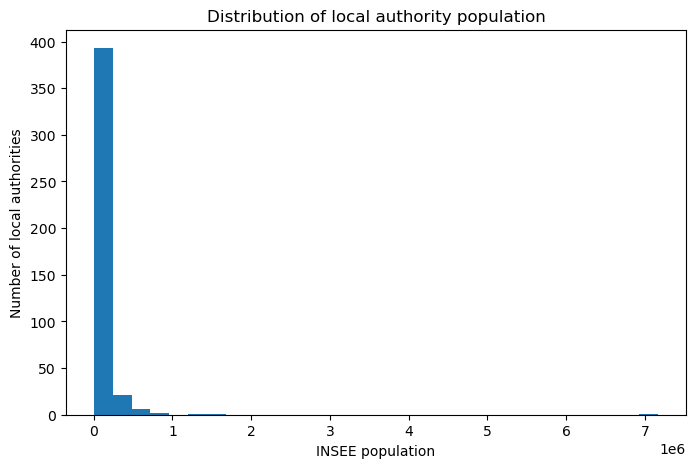

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(df["population_insee"], bins=30)

plt.xlabel("INSEE population")
plt.ylabel("Number of local authorities")
plt.title("Distribution of local authority population")

plt.show()

### Log transformation of population

A logarithmic transformation is applied to reduce the influence of extreme population values and make differences between local authorities easier to analyse.

In [6]:
import numpy as np

df["log_population"] = np.log(df["population_insee"])

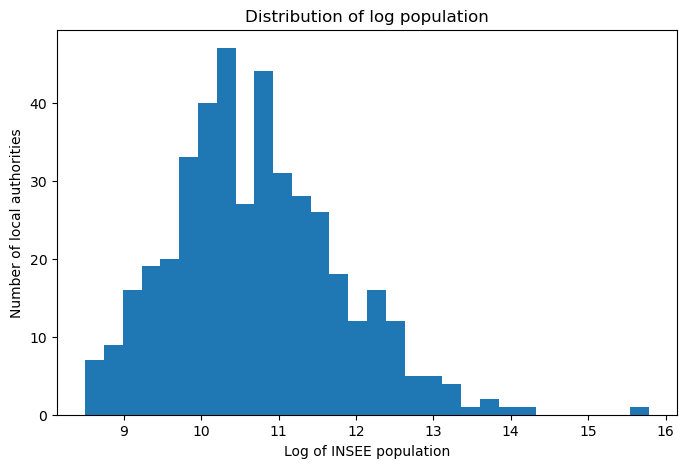

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["log_population"], bins=30)

plt.xlabel("Log of INSEE population")
plt.ylabel("Number of local authorities")
plt.title("Distribution of log population")

plt.show()

The logarithmic transformation produces a substantially more balanced distribution and will therefore be useful for subsequent analyses involving population size.

## 4. Correlation analysis

Spearman correlations are used to examine the relationships between CAE and ECI ratings and the main demographic and financial variables.

This rank-based measure is appropriate because the ratings are ordinal and several quantitative variables have asymmetric distributions.

In [8]:
variables_corr = [
    "etoiles_cae",
    "etoiles_eci",
    "population_insee",
    "revenu",
    "potentiel_fiscal",
    "potentiel_fiscal_hab",
    "cif"
]

correlations = df[variables_corr].corr(method="spearman")

correlations.round(2)

,etoiles_cae,etoiles_eci,population_insee,revenu,potentiel_fiscal,potentiel_fiscal_hab,cif
etoiles_cae,1.00,0.27,0.53,0.54,0.55,0.42,0.10
etoiles_eci,0.27,1.00,0.23,0.23,0.22,0.11,0.01
population_insee,0.53,0.23,1.00,0.99,0.95,0.51,-0.01
revenu,0.54,0.23,0.99,1.00,0.95,0.52,-0.04
potentiel_fiscal,0.55,0.22,0.95,0.95,1.00,0.72,0.02
potentiel_fiscal_hab,0.42,0.11,0.51,0.52,0.72,1.00,0.14
cif,0.10,0.01,-0.01,-0.04,0.02,0.14,1.00


CAE ratings show moderate positive associations with population, revenue and fiscal potential. The strongest correlations are observed with fiscal potential (0.55), revenue (0.54) and population (0.53). Fiscal potential per capita is also positively associated with CAE ratings (0.42).

In contrast, ECI ratings show substantially weaker associations with the demographic and financial variables considered here.

The very strong correlations between population, revenue and total fiscal potential also suggest substantial overlap between these measures, which will need to be considered in the statistical modelling.

## 5. Fiscal potential and CAE rating

Fiscal potential per capita is examined across CAE rating levels to determine whether financial capacity differs according to the level of CAE performance.

In [9]:
df.groupby("etoiles_cae")["potentiel_fiscal_hab"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
etoiles_cae,,,
0,154,339.78,319.54
1,137,380.63,368.86
2,72,435.60,411.69
3,41,527.52,519.50
4,11,534.09,500.49
5,10,732.83,664.88


<Figure size 900x500 with 0 Axes>

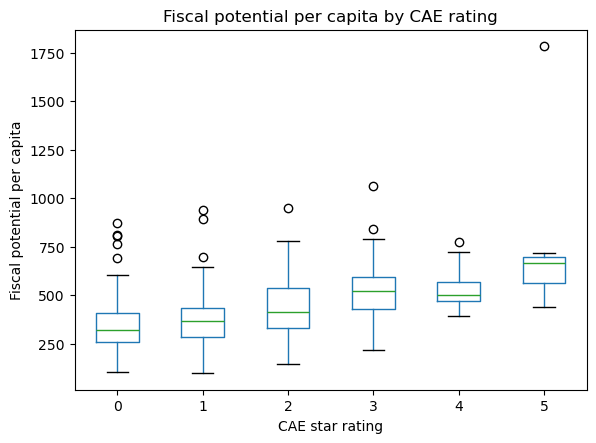

In [10]:
plt.figure(figsize=(9, 5))

df.boxplot(
    column="potentiel_fiscal_hab",
    by="etoiles_cae",
    grid=False
)

plt.xlabel("CAE star rating")
plt.ylabel("Fiscal potential per capita")
plt.title("Fiscal potential per capita by CAE rating")
plt.suptitle("")

plt.show()

Fiscal potential per capita generally increases with the CAE rating. The median rises from approximately 320 per capita for local authorities with no CAE stars to approximately 665 for those with five stars.

However, substantial dispersion remains within rating categories, and the highest CAE levels contain relatively few observations. These results therefore indicate an association between financial capacity and CAE performance, but do not establish a causal relationship.

## 6. Population and CAE rating

Population size is also compared across CAE rating levels to examine whether larger local authorities tend to achieve higher CAE ratings.

In [11]:
df.groupby("etoiles_cae")["population_insee"].agg(
    ["count", "mean", "median"]
).round(0)

,count,mean,median
etoiles_cae,,,
0,154,35038.0,23544.0
1,137,65679.0,41797.0
2,72,97244.0,65749.0
3,41,304007.0,104047.0
4,11,305601.0,234112.0
5,10,627962.0,502934.0


Median population increases steadily with the CAE rating, from approximately 23,500 inhabitants for local authorities with no CAE stars to more than 500,000 for those with five stars.

This pattern suggests that higher CAE ratings are associated with larger local authorities. However, the small number of observations in the highest rating categories means that these differences should be interpreted cautiously.

## 7. Main findings

The exploratory analysis highlights several patterns:

- local authorities differ substantially in population size and financial capacity;
- higher CAE ratings are associated with larger populations and greater fiscal potential per capita;
- population, revenue and total fiscal potential are strongly correlated with each other;
- ECI ratings show weaker relationships with the demographic and financial characteristics examined here.

These findings are descriptive and should not be interpreted as causal effects. They provide the basis for the statistical analysis developed in the next notebook.